In [264]:
import pandas as pd
import matplotlib.pyplot as plt

In [265]:
df_sismos=pd.read_csv("SSNMX_catalogo_20000101_20051231.csv",skiprows=4,skipfooter=7,engine="python")
df_sismos["Magnitud"]=pd.to_numeric(df_sismos["Magnitud"], errors="coerce")
df_sismos

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2000-01-01,00:55:51,3.5,17.12,-100.57,29.0,"13 km al SURESTE de TECPAN, GRO",2000-01-01,06:55:51,revisado
1,2000-01-02,11:35:17,4.3,16.07,-97.35,16.0,"11 km al NORESTE de RIO GRANDE, OAX",2000-01-02,17:35:17,revisado
2,2000-01-02,22:32:36,3.9,16.01,-98.62,6.0,"71 km al SUROESTE de PINOTEPA NACIONAL, OAX",2000-01-03,04:32:36,revisado
3,2000-01-03,01:55:15,3.4,17.74,-96.88,83.0,"53 km al SURESTE de TEPELMEME, OAX",2000-01-03,07:55:15,revisado
4,2000-01-03,04:08:44,3.5,18.30,-94.91,15.0,"25 km al SURESTE de CATEMACO, VER",2000-01-03,10:08:44,revisado
...,...,...,...,...,...,...,...,...,...,...
7958,2005-12-30,06:19:12,4.0,16.03,-98.31,6.0,"44 km al SUROESTE de PINOTEPA NACIONAL, OAX",2005-12-30,12:19:12,revisado
7959,2005-12-30,11:24:00,4.4,16.19,-93.85,55.0,"7 km al SURESTE de ARRIAGA , CHIS",2005-12-30,17:24:00,revisado
7960,2005-12-30,18:35:41,4.3,15.77,-93.51,92.0,"34 km al NOROESTE de PIJIJIAPAN, CHIS",2005-12-31,00:35:41,revisado
7961,2005-12-30,22:34:47,4.2,15.69,-94.80,20.0,"69 km al SURESTE de SALINA CRUZ, OAX",2005-12-31,04:34:47,revisado


In [266]:
df_sismos.dropna(inplace=True)
df_sismos

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2000-01-01,00:55:51,3.5,17.12,-100.57,29.0,"13 km al SURESTE de TECPAN, GRO",2000-01-01,06:55:51,revisado
1,2000-01-02,11:35:17,4.3,16.07,-97.35,16.0,"11 km al NORESTE de RIO GRANDE, OAX",2000-01-02,17:35:17,revisado
2,2000-01-02,22:32:36,3.9,16.01,-98.62,6.0,"71 km al SUROESTE de PINOTEPA NACIONAL, OAX",2000-01-03,04:32:36,revisado
3,2000-01-03,01:55:15,3.4,17.74,-96.88,83.0,"53 km al SURESTE de TEPELMEME, OAX",2000-01-03,07:55:15,revisado
4,2000-01-03,04:08:44,3.5,18.30,-94.91,15.0,"25 km al SURESTE de CATEMACO, VER",2000-01-03,10:08:44,revisado
...,...,...,...,...,...,...,...,...,...,...
7958,2005-12-30,06:19:12,4.0,16.03,-98.31,6.0,"44 km al SUROESTE de PINOTEPA NACIONAL, OAX",2005-12-30,12:19:12,revisado
7959,2005-12-30,11:24:00,4.4,16.19,-93.85,55.0,"7 km al SURESTE de ARRIAGA , CHIS",2005-12-30,17:24:00,revisado
7960,2005-12-30,18:35:41,4.3,15.77,-93.51,92.0,"34 km al NOROESTE de PIJIJIAPAN, CHIS",2005-12-31,00:35:41,revisado
7961,2005-12-30,22:34:47,4.2,15.69,-94.80,20.0,"69 km al SURESTE de SALINA CRUZ, OAX",2005-12-31,04:34:47,revisado


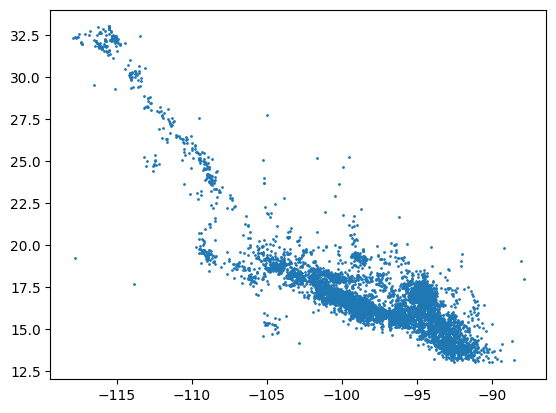

In [267]:
plt.scatter(df_sismos["Longitud"],df_sismos["Latitud"],s=1)

In [268]:
x0=-118
y0=32.5
xf=-89
yf=16

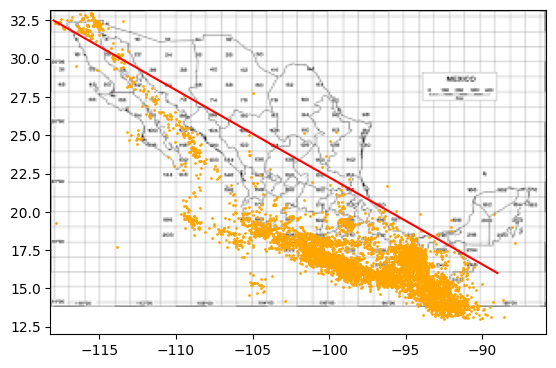

In [269]:
im=plt.imread("México.png")
fig, ax = plt.subplots()
x_min=-118.2
x_max=-85.8
y_min=13.8 
y_max=33.2
im=ax.imshow(im,extent=[x_min,x_max,y_min,y_max])
ax.scatter(df_sismos["Longitud"],df_sismos["Latitud"],s=1, color= "orange")
ax.plot([x0,xf],[y0,yf],color="red")


Obtenemos la pendiente de la recta generada en el codigo anterior, para asi facilitar la separación entre los sismos registrados en la parte Norte de la parte Sur. 

In [271]:
m = (yf - y0) / (xf - x0)
y_linea = m * (df_sismos["Longitud"] - x0) + y0

df_sismos_north = df_sismos[df_sismos["Latitud"] >= y_linea]
df_sismos_south = df_sismos[df_sismos["Latitud"] < y_linea]

En la línea de código:

```python
y_linea = m * (df_sismos["Longitud"] - x0) + y0

Explicitamente indica cuál es la latitud de la línea roja para cada longitud

Para lo siguiente: 
```python
df_sismos_north = df_sismos[df_sismos["Latitud"] >= y_linea]
df_sismos_south = df_sismos[df_sismos["Latitud"] < y_linea]

Compara su latitud real contra la latitud de la linea.
si se cumple que:
```python
>= y_linea
entonces, el punto esta arriba de la linea

si se cumple que:
```python
< y_linea
entonces, el punto esta debajo de la linea 

In [272]:
img = plt.imread("México.png")

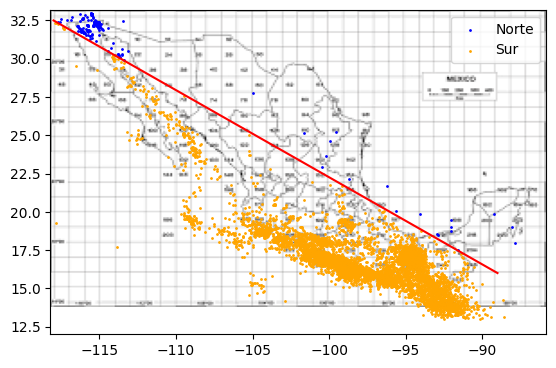

In [273]:
fig, ax = plt.subplots()
ax.imshow(img, extent=[x_min, x_max, y_min, y_max]) 
ax.scatter(df_sismos_north["Longitud"], df_sismos_north["Latitud"],s=1, color="blue", label="Norte")
ax.scatter(df_sismos_south["Longitud"], df_sismos_south["Latitud"],s=1, color="orange", label="Sur")
ax.plot([x0, xf], [y0, yf], color="red")
ax.legend()
plt.show()

In [274]:
df_sismos_north

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
29,2000-01-14,05:04:38,3.0,32.17,-116.49,9.0,"36 km al NORESTE de ENSENADA, BC",2000-01-14,11:04:38,revisado
30,2000-01-14,16:22:54,4.3,19.46,-92.01,10.0,"92 km al NORTE de CD DEL CARMEN, CAMP",2000-01-14,22:22:54,revisado
68,2000-02-01,01:40:27,2.8,32.60,-116.16,9.0,"45 km al ESTE de TECATE, BC",2000-02-01,07:40:27,revisado
84,2000-02-06,04:16:52,3.1,32.68,-116.09,11.0,"49 km al OESTE de SANTA ISABEL, BC",2000-02-06,10:16:52,revisado
96,2000-02-10,00:20:32,3.0,31.82,-116.17,15.0,"39 km al NORESTE de RODOLFO SANCHEZ T(MRO), BC",2000-02-10,06:20:32,revisado
...,...,...,...,...,...,...,...,...,...,...
7668,2005-10-02,10:10:01,3.9,32.11,-115.74,5.0,"60 km al SUR de SANTA ISABEL, BC",2005-10-02,15:10:01,revisado
7759,2005-10-31,07:41:33,3.9,30.52,-113.11,10.0,"94 km al OESTE de H CABORCA, SON",2005-10-31,13:41:33,revisado
7767,2005-11-01,13:40:18,3.7,31.83,-115.83,4.0,"71 km al ESTE de RODOLFO SANCHEZ T(MRO), BC",2005-11-01,19:40:18,revisado
7880,2005-12-05,00:11:21,4.2,18.49,-92.86,68.0,"23 km al OESTE de FRONTERA, TAB",2005-12-05,06:11:21,revisado


In [275]:
df_sismos_south

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2000-01-01,00:55:51,3.5,17.12,-100.57,29.0,"13 km al SURESTE de TECPAN, GRO",2000-01-01,06:55:51,revisado
1,2000-01-02,11:35:17,4.3,16.07,-97.35,16.0,"11 km al NORESTE de RIO GRANDE, OAX",2000-01-02,17:35:17,revisado
2,2000-01-02,22:32:36,3.9,16.01,-98.62,6.0,"71 km al SUROESTE de PINOTEPA NACIONAL, OAX",2000-01-03,04:32:36,revisado
3,2000-01-03,01:55:15,3.4,17.74,-96.88,83.0,"53 km al SURESTE de TEPELMEME, OAX",2000-01-03,07:55:15,revisado
4,2000-01-03,04:08:44,3.5,18.30,-94.91,15.0,"25 km al SURESTE de CATEMACO, VER",2000-01-03,10:08:44,revisado
...,...,...,...,...,...,...,...,...,...,...
7958,2005-12-30,06:19:12,4.0,16.03,-98.31,6.0,"44 km al SUROESTE de PINOTEPA NACIONAL, OAX",2005-12-30,12:19:12,revisado
7959,2005-12-30,11:24:00,4.4,16.19,-93.85,55.0,"7 km al SURESTE de ARRIAGA , CHIS",2005-12-30,17:24:00,revisado
7960,2005-12-30,18:35:41,4.3,15.77,-93.51,92.0,"34 km al NOROESTE de PIJIJIAPAN, CHIS",2005-12-31,00:35:41,revisado
7961,2005-12-30,22:34:47,4.2,15.69,-94.80,20.0,"69 km al SURESTE de SALINA CRUZ, OAX",2005-12-31,04:34:47,revisado
